In [19]:
import pandas as pd
import numpy as np
import multiprocessing
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn import metrics
import gc
from time import time
import datetime
from tqdm import tqdm_notebook
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold,GroupKFold
from sklearn.metrics import roc_auc_score
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
warnings.simplefilter('ignore')
%matplotlib inline

In [20]:
df = pd.read_csv('Dataset/train.csv')
df.isnull().sum()

Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

In [23]:
# Drop all rows with Nan in age column
df = df.dropna(subset=['age'])

In [4]:
df.drop(columns=['Customer_ID','age'], inplace=True)

In [ ]:
def credit_card_feature_engineering(df):
    """
    Perform comprehensive feature engineering on credit card default dataset

    Args:
        df: DataFrame with credit card default data
    
    Returns:
        DataFrame with additional engineered features
    """
    df_fe = df.copy()
    
    # Payment delay features
    payment_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
    df_fe['count_delayed_payments'] = (df_fe[payment_cols] > 0).sum(axis=1)
    df_fe['max_payment_delay'] = df_fe[payment_cols].max(axis=1)
    df_fe['avg_payment_delay'] = df_fe[payment_cols].mean(axis=1)
    df_fe['has_severe_delay'] = (df_fe[payment_cols] >= 2).any(axis=1).astype(int)
    
    # Bill and payment amount features
    bill_cols = ['Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6']
    pay_cols = ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']
    
    df_fe['total_bill_amount'] = df_fe[bill_cols].sum(axis=1)
    df_fe['total_payment_amount'] = df_fe[pay_cols].sum(axis=1)
    df_fe['total_payment_ratio'] = df_fe['total_payment_amount'] / df_fe['total_bill_amount'].replace(0, np.nan)
    df_fe['total_payment_ratio'] = df_fe['total_payment_ratio'].fillna(0)
    
    # Variability features
    df_fe['bill_amount_std'] = df_fe[bill_cols].std(axis=1)
    df_fe['payment_amount_std'] = df_fe[pay_cols].std(axis=1)
    df_fe['recent_payment_ratio'] = (df_fe['pay_amt1'] + df_fe['pay_amt2']) / (df_fe['total_payment_amount'] + 1)
    
    # NEW FEATURES - Credit utilization patterns
    df_fe['avg_bill_amount'] = df_fe[bill_cols].mean(axis=1)
    df_fe['credit_utilization'] = df_fe['avg_bill_amount'] / df_fe['LIMIT_BAL']
    df_fe['max_credit_utilization'] = df_fe[bill_cols].max(axis=1) / df_fe['LIMIT_BAL']
    
    # NEW FEATURES - Payment behavior patterns
    df_fe['payment_consistency'] = 1 - (df_fe['payment_amount_std'] / (df_fe['total_payment_amount'] + 1))
    df_fe['consecutive_delays'] = 0
    for i in range(len(payment_cols) - 1):
        df_fe['consecutive_delays'] += ((df_fe[payment_cols[i]] > 0) & (df_fe[payment_cols[i+1]] > 0)).astype(int)
    
    # NEW FEATURES - Financial stress indicators
    df_fe['bill_increasing_trend'] = (df_fe['Bill_amt1'] > df_fe['Bill_amt6']).astype(int)
    df_fe['payment_decreasing_trend'] = (df_fe['pay_amt1'] < df_fe['pay_amt6']).astype(int)
    df_fe['financial_stress_score'] = (df_fe['has_severe_delay'] + 
                                       df_fe['bill_increasing_trend'] + 
                                       df_fe['payment_decreasing_trend'] + 
                                       (df_fe['credit_utilization'] > 0.8).astype(int))
    
    # NEW FEATURES - Monthly payment patterns
    for i in range(1, 7):
        df_fe[f'payment_to_bill_ratio_{i}'] = df_fe[f'pay_amt{i}'] / (df_fe[f'Bill_amt{i}'] + 1)
    
    # NEW FEATURES - Education and demographic interactions
    df_fe['high_education_low_limit'] = ((df_fe['education'] <= 2) & (df_fe['LIMIT_BAL'] < 50000)).astype(int)
    df_fe['married_female'] = ((df_fe['marriage'] == 1) & (df_fe['sex'] == 0)).astype(int)
    
    # NEW FEATURES - Risk indicators
    df_fe['zero_payment_months'] = (df_fe[pay_cols] == 0).sum(axis=1)
    df_fe['high_utilization_low_payment'] = ((df_fe['credit_utilization'] > 0.7) & 
                                             (df_fe['total_payment_ratio'] < 0.1)).astype(int)
    
    return df_fe


df_fe = credit_card_feature_engineering(df)

In [6]:
# check for nan values
def check_nan(df):
    nan_counts = df.isna().sum()
    nan_counts = nan_counts[nan_counts > 0]
    if not nan_counts.empty:
        print("Columns with NaN values:")
        print(nan_counts)
    else:
        print("No NaN values found in the DataFrame.")
    
check_nan(df_fe)

No NaN values found in the DataFrame.


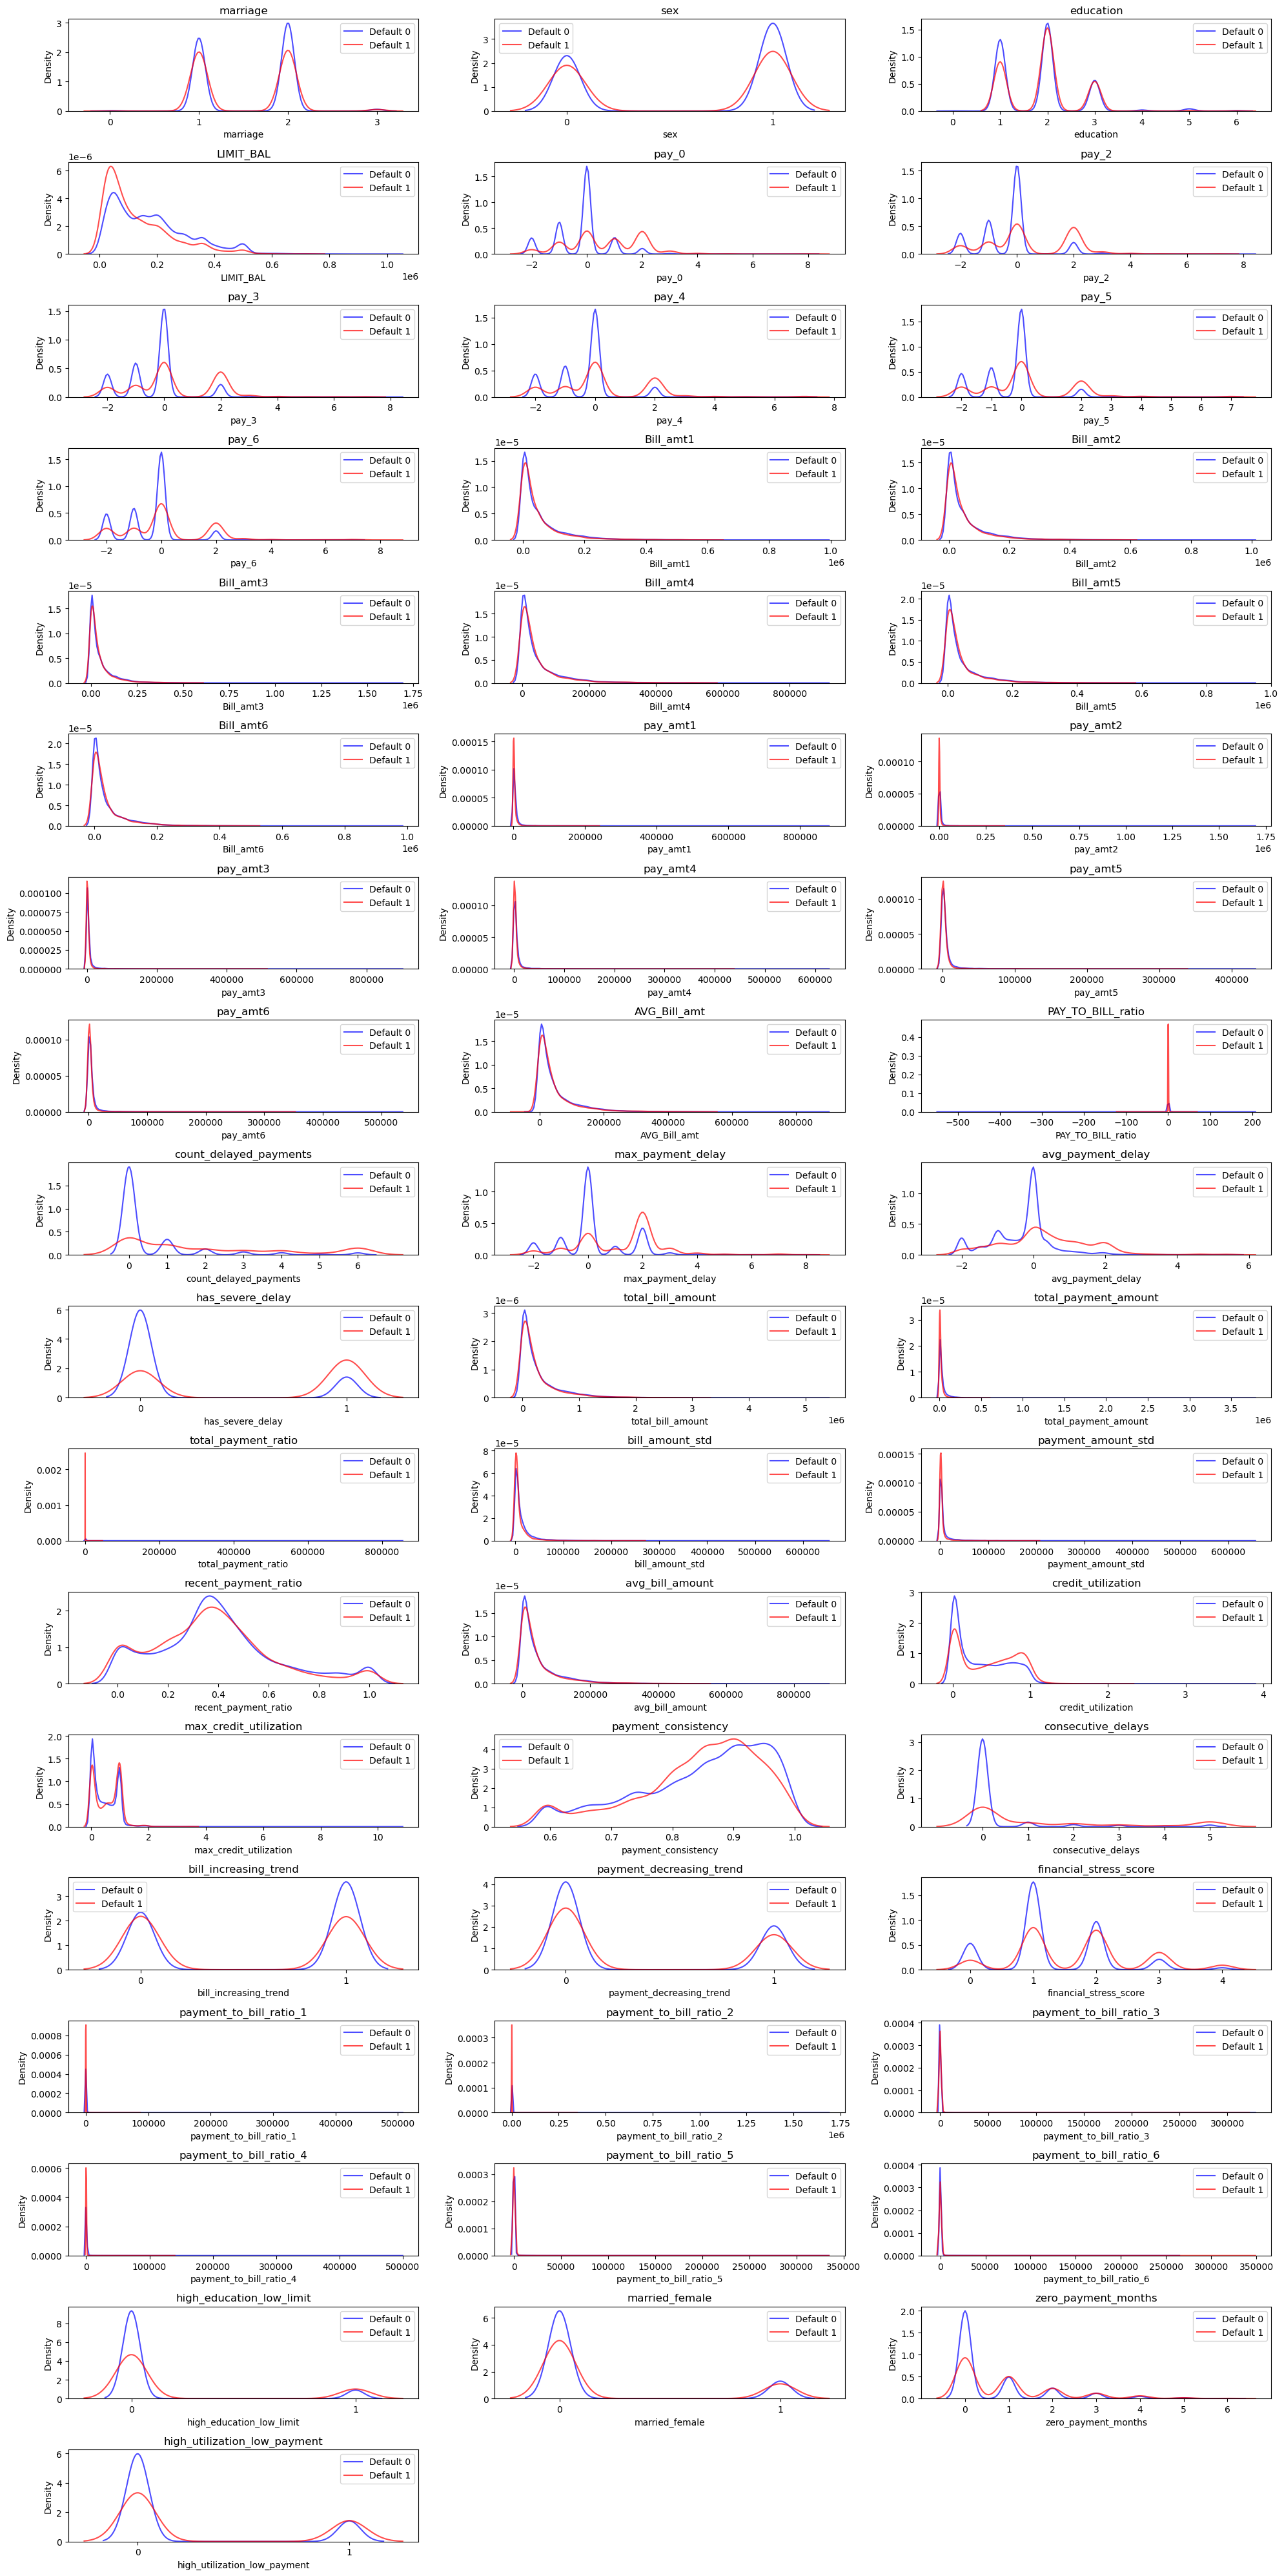

In [7]:
features = df_fe.drop(columns='next_month_default').columns
n_cols = 3
n_rows = -(-len(features) // n_cols)  # Ceiling division

plt.figure(figsize=(20, 40))
for i, f in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    for cls, color in zip([0, 1], ['blue', 'red']):
        sns.kdeplot(df_fe[df_fe['next_month_default'] == cls][f], label=f'Default {cls}', alpha=0.7, color=color)
    plt.title(f)
    plt.xlabel(f)
    if df_fe[f].nunique() < 10:
        plt.xticks(sorted(df_fe[f].unique()))
    plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# print all column names
print("Column names in the DataFrame:")
for col in df_fe.columns:
    print(col)

Column names in the DataFrame:
marriage
sex
education
LIMIT_BAL
pay_0
pay_2
pay_3
pay_4
pay_5
pay_6
Bill_amt1
Bill_amt2
Bill_amt3
Bill_amt4
Bill_amt5
Bill_amt6
pay_amt1
pay_amt2
pay_amt3
pay_amt4
pay_amt5
pay_amt6
AVG_Bill_amt
PAY_TO_BILL_ratio
next_month_default
count_delayed_payments
max_payment_delay
avg_payment_delay
has_severe_delay
total_bill_amount
total_payment_amount
total_payment_ratio
bill_amount_std
payment_amount_std
recent_payment_ratio
avg_bill_amount
credit_utilization
max_credit_utilization
payment_consistency
consecutive_delays
bill_increasing_trend
payment_decreasing_trend
financial_stress_score
payment_to_bill_ratio_1
payment_to_bill_ratio_2
payment_to_bill_ratio_3
payment_to_bill_ratio_4
payment_to_bill_ratio_5
payment_to_bill_ratio_6
high_education_low_limit
married_female
zero_payment_months
high_utilization_low_payment


In [9]:
columns_to_transform = [
    'LIMIT_BAL', 
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
    'total_bill_amount',
    'total_payment_amount',
    'bill_amount_std',
    'payment_amount_std',
    ]

In [10]:
def apply_boxcox_transform(df, column_name):
    """
    Apply Box-Cox transformation to a specific column
    """
    df_transformed = df.copy()
    data = df_transformed[column_name].values
    
    min_val = data.min()
    if min_val <= 0:
        shift = abs(min_val) + 1e-6
        data_shifted = data + shift
    else:
        data_shifted = data
    
    # Apply Box-Cox transformation
    transformed_data, lambda_param = stats.boxcox(data_shifted)
    df_transformed[f"{column_name}_boxcox"] = transformed_data
    
    return df_transformed, lambda_param

def apply_standardization(df, column_name):
    """
    Apply standardization (z-score normalization) to a specific column
    """
    df_transformed = df.copy()
    scaler = StandardScaler()
    data_reshaped = df_transformed[column_name].values.reshape(-1, 1)
    transformed_data = scaler.fit_transform(data_reshaped)
    df_transformed[f"{column_name}_standardized"] = transformed_data.flatten()
    return df_transformed, scaler

for col in columns_to_transform:
    df_fe, lambda_param = apply_boxcox_transform(df_fe, col)
    df_fe, scaler = apply_standardization(df_fe, col)
    print(f"Applied transformations to {col}: BoxCox and Standardization")

Applied transformations to LIMIT_BAL: BoxCox and Standardization
Applied transformations to Bill_amt1: BoxCox and Standardization
Applied transformations to Bill_amt2: BoxCox and Standardization
Applied transformations to Bill_amt3: BoxCox and Standardization
Applied transformations to Bill_amt4: BoxCox and Standardization
Applied transformations to Bill_amt5: BoxCox and Standardization
Applied transformations to Bill_amt6: BoxCox and Standardization
Applied transformations to pay_amt1: BoxCox and Standardization
Applied transformations to pay_amt2: BoxCox and Standardization
Applied transformations to pay_amt3: BoxCox and Standardization
Applied transformations to pay_amt4: BoxCox and Standardization
Applied transformations to pay_amt5: BoxCox and Standardization
Applied transformations to pay_amt6: BoxCox and Standardization
Applied transformations to total_bill_amount: BoxCox and Standardization
Applied transformations to total_payment_amount: BoxCox and Standardization
Applied tran

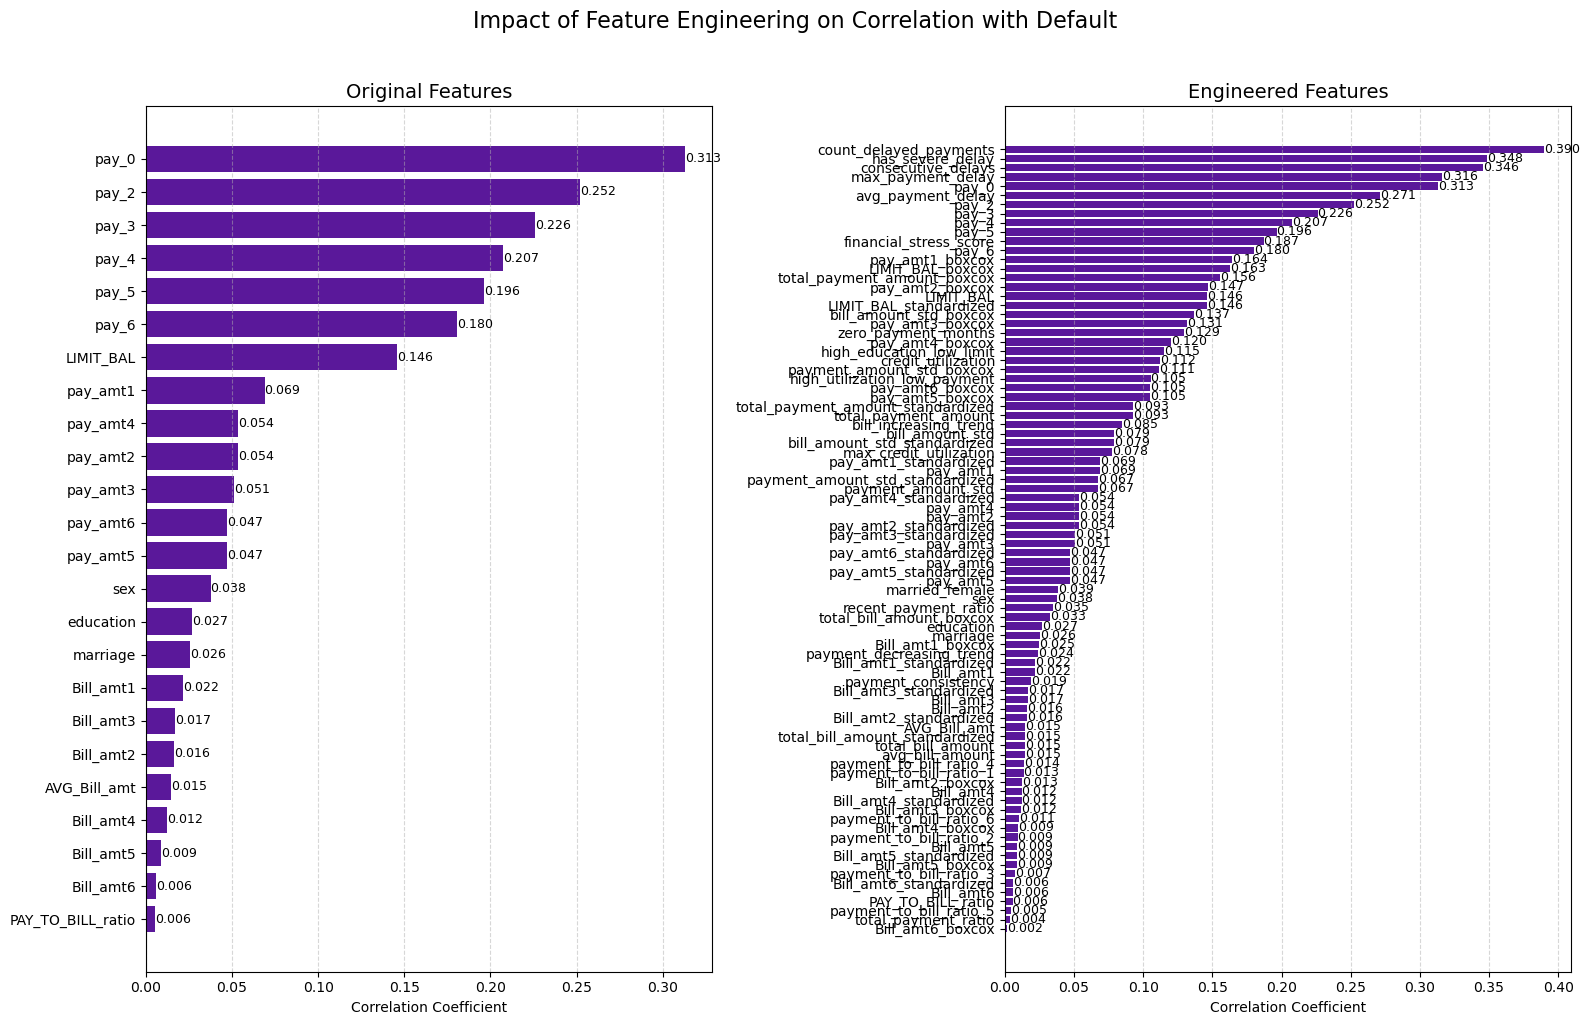

In [11]:
# Calculate correlations with the target variable
corr = df.drop(columns=['next_month_default']).corrwith(df['next_month_default']).abs().sort_values(ascending=True)
corr_fe = df_fe.drop(columns=['next_month_default']).corrwith(df_fe['next_month_default']).abs().sort_values(ascending=True)

# # Filter to show only the most relevant features for better visualization
# top_n = 30
# corr = corr.tail(top_n)
# corr_fe = corr_fe.tail(top_n)

def plot_corr(ax, corr, title):
    colors = ['#5a189a' if x > 0 else '#c77dff' for x in corr]
    bars = ax.barh(corr.index, corr.values, color=colors)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Correlation Coefficient')
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    for bar in bars:
        w = bar.get_width()
        ax.text(w if w > 0 else w - 0.05, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', ha='left' if w > 0 else 'right', fontsize=9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
plot_corr(ax1, corr, 'Original Features')
plot_corr(ax2, corr_fe, 'Engineered Features')
plt.suptitle('Impact of Feature Engineering on Correlation with Default', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# # use top 30 col only
# top_features = corr_fe.tail(30).index.tolist()

# # Add engineered features to the DataFrame
# df_fe = df_fe[top_features + ['next_month_default']]
# # Split the data into features and target variable
# X = df_fe.drop(columns='next_month_default')
# y = df_fe['next_month_default']


In [12]:
X = df_fe.drop(columns=['next_month_default'])
y = df_fe['next_month_default']

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score,fbeta_score, recall_score,precision_score, confusion_matrix, classification_report, roc_auc_score, make_scorer

from sklearn.model_selection import cross_val_score

from sklearn.metrics import precision_recall_fscore_support

In [14]:
def get_f2_score(y_true, y_pred):
    """
    Calculate F2 score which emphasizes recall more than precision.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
    
    Returns:
        F2 score
    """
    return fbeta_score(y_true, y_pred, beta=2)

In [15]:
def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] 

    print(f"\n==== {name} ====")
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
    print("Classification Report:\n", classification_report(y, y_pred))
    print(f"Accuracy     : {accuracy_score(y, y_pred):.4f}")
    print(f"Precision    : {precision_score(y, y_pred):.4f}")
    print(f"Recall       : {recall_score(y, y_pred):.4f}")
    print(f"F1 Score     : {f1_score(y, y_pred):.4f}")
    print(f"F2 Score     : {fbeta_score(y, y_pred, beta=2):.4f}")
    print(f"ROC-AUC      : {roc_auc_score(y, y_proba):.4f}")
    print("-" * 40)

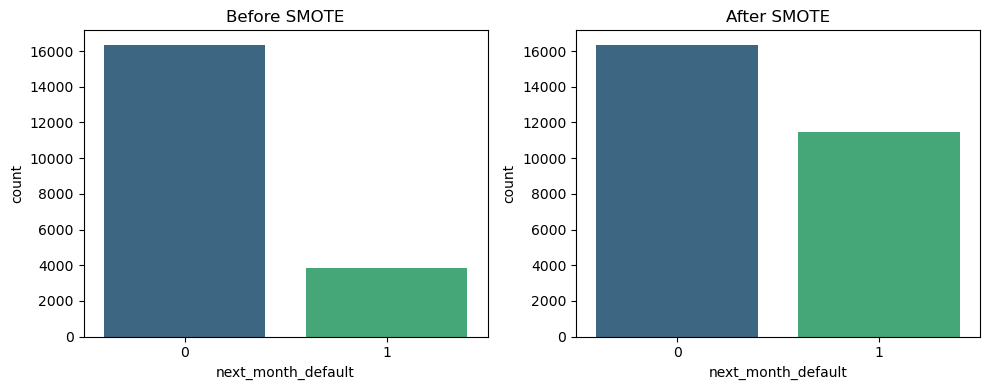

In [16]:
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Adjust sampling_strategy for less oversampling
smote = SMOTE(sampling_strategy=0.7)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Plot before and after
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, title in zip(axs, [y_train, y_res], ['Before SMOTE', 'After SMOTE']):
    sns.countplot(x=y, ax=ax, palette='viridis')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [17]:
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    evaluate_model(model.__class__.__name__, model, X_val, y_val)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}


for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")
    train_and_evaluate_model(model, X_res, y_res, X_val, y_val)



Training and evaluating Logistic Regression...

==== LogisticRegression ====
Confusion Matrix:
 [[3608  487]
 [ 604  351]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87      4095
           1       0.42      0.37      0.39       955

    accuracy                           0.78      5050
   macro avg       0.64      0.62      0.63      5050
weighted avg       0.77      0.78      0.78      5050

Accuracy     : 0.7840
Precision    : 0.4189
Recall       : 0.3675
F1 Score     : 0.3915
F2 Score     : 0.3768
ROC-AUC      : 0.7029
----------------------------------------

Training and evaluating XGBoost...

==== XGBClassifier ====
Confusion Matrix:
 [[3820  275]
 [ 607  348]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90      4095
           1       0.56      0.36      0.44       955

    accuracy                           0.83      5050
   